## Figures S1, S2 — Floquet stability chart and Bloch waves in classical periodic media

This notebook reproduces **Figures S1 and S2** of the supplementary material.

It studies electromagnetic waves in a **positive-$F(x)$** 1D periodic medium
($\varepsilon(x) = \varepsilon_0[1 + \eta\cos(2\pi x/\lambda)]$ with $\eta < 1$,
so $\varepsilon(x) > 0$ everywhere) — the classical photonic crystal regime.


In [31]:
import numpy as np
import scipy.special as sp
from scipy.sparse import diags
from scipy.optimize import fsolve
from scipy.sparse.linalg import eigs
from scipy.linalg import eigh
from scipy.special import mathieu_a, mathieu_cem, mathieu_b, mathieu_sem
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from numpy import linalg as LA
import scipy.linalg
import cmath as cm
import matplotlib.pyplot as plt

In [32]:
def equation_lin(t, y, toto, titi):  
    qq, pp  = y
    #dydt = [pp, -(toto-2*titi*np.cos(2*t))*qq]
    dydt = [pp, -(toto+2*titi*np.cos(2*t))*qq]
    return dydt


In [33]:
def find(element, vector):
    
    """ Function returning index of an element in a vector """
    
    for i in range(len(vector)):
        if vector[i] == element:
            return (i)

In [34]:
def sol_comp_mode_floquet(t, y, a, q, sn):
    JJ = np.array([ [0.,1 ],
                       [-a+2*q*np.cos(2*t),0.] ],dtype=complex)
    Is = np.array([ [sn,0.],
                       [0.,sn] ],dtype=complex)
    mat_B   = JJ - Is 
    dydt    = np.dot(mat_B,y)
    return dydt



In [35]:
from scipy.signal import find_peaks

def find_fft_peaks(fft_wave_shifted, k, height=None, distance=None):
    """
    Find the peaks of the FFT and their corresponding wavenumbers.
    
    Parameters:
    - fft_wave_shifted (np.ndarray): The shifted FFT amplitude array.
    - k (np.ndarray): The wavenumbers corresponding to the FFT.
    - height (float, optional): Minimum amplitude for a peak. Default is None.
    - distance (int, optional): Minimum distance between peaks in indices. Default is None.
    
    Returns:
    - peak_k (np.ndarray): Wavenumbers corresponding to the peaks.
    - peak_amplitudes (np.ndarray): Amplitudes of the peaks.
    """
    # Find peaks in the FFT amplitude
    peaks, _ = find_peaks(np.abs(fft_wave_shifted), height=height, distance=distance)
    
    # Extract wavenumbers and amplitudes at the peaks
    peak_k = k[peaks]
    peak_amplitudes = np.abs(fft_wave_shifted[peaks])
    
    # Return unique peaks sorted by wavenumber
    unique_indices = np.argsort(peak_k)
    return peak_k[unique_indices], peak_amplitudes[unique_indices]

In [36]:
def compute_hill_eigenvalues1(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    Hmax = 10
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute eigenvalues and eigenvectors
    eigtot, V = np.linalg.eig(HILL)
    eigtot = eigtot[np.argsort(np.imag(eigtot))]  # Sort eigenvalues by imaginary part

    # Weighted arithmetic mean (center of mass) calculation
    XX = np.repeat(np.arange(-Hmax, Hmax + 1), nstate)
    abs_V = np.abs(V)
    Wmean = np.sum(XX[:, None] * abs_V, axis=0) / np.sum(abs_V, axis=0)

    # Sort by weighted arithmetic mean
    sorted_indices = np.argsort(Wmean)
    Wmean_sorted = Wmean[sorted_indices]

    # Filter based on balanced eigenvectors
    ind2 = np.where((np.round(Wmean_sorted, 6) <= 0.5) & (np.round(Wmean_sorted, 6) > -0.5))[0]

    # Select the most converged eigenvalues and eigenvectors
    if len(ind2) == nstate:
        # Further sort by the absolute imaginary part of eigenvalues
        ind3 = np.argsort(np.abs(np.imag(eigtot[sorted_indices[ind2]])))
        Fexponents = eigtot[sorted_indices[ind2[ind3]]]
        VecHill = V[:, sorted_indices[ind2[ind3]]]
    else:
        # If not enough converged eigenvalues, return NaN arrays
        Fexponents = np.full((nstate,), np.nan + 1j * np.nan)
        VecHill = np.full((nstate * (2 * Hmax + 1), nstate), np.nan + 1j * np.nan)

    return Fexponents, VecHill


In [37]:
def compute_hill_eigenvalues2(delta, eps, TT):
    """
    Computes the sorted eigenvalues of the Hill matrix for the given parameters.

    Parameters:
        delta (float): Parameter delta.
        beta (float): Parameter beta.
        Q (float): Parameter Q.
        eps (float): Parameter epsilon.
        TT (float): Period.
        Hmax (int): Truncation order of the Hill matrix (default is 5).

    Returns:
        np.ndarray: Sorted eigenvalues of the Hill matrix.
    """
    nstate = 2  # Dimension of the state space
    solfinal = np.zeros(nstate, dtype=complex)
    Hmax = 12
    # Initialize the Hill matrix
    HILL = np.zeros((nstate * (2 * Hmax + 1), nstate * (2 * Hmax + 1)), dtype=complex)
    
    # Identity matrix
    II = np.eye(nstate)
    
    # Constant term of the Jacobian
    J0 = np.array([[0, 1], [-delta, 0.]])
    
    # Term in exp(2i/tau) and exp(-2i/tau)
    Jun = np.array([[0, 0], [-eps, 0]])
    
    # Populate the Hill matrix
    for t in range(1, Hmax * 2 + 2):
        idx = (t - 1) * nstate
        HILL[idx:idx + nstate, idx:idx + nstate] = J0 + (Hmax - (t - 1)) * (2 * np.pi / TT) * 1j * II
        if t > 1:
            prev_idx = (t - 2) * nstate
            HILL[prev_idx:prev_idx + nstate, idx:idx + nstate] = Jun
            HILL[idx:idx + nstate, prev_idx:prev_idx + nstate] = Jun
    
    # Compute the eigenvalues
    eighill = np.linalg.eigvals(HILL)
    
    # Filter eigenvalues based on the imaginary part condition
    condition = np.abs(np.imag(eighill)) < (np.pi / TT + 10**(-Hmax))
    solhill = eighill[condition]
    
    if solhill.size == nstate:
        solfinal = solhill
    elif solhill.size == 2*nstate:
        solfinal[0] = np.abs(np.real(solhill[0])) + 1j*np.abs(np.imag(solhill[0]))
        solfinal[1] = -solfinal[0]
            
    return solfinal

In [38]:
def equation_a(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_a(nn, q) - (2 * s0 * q / s1)

def equation_b(q, nn, s0, s1):
    """Defines the modified Mathieu equation with s0 and s1 as parameters."""
    return mathieu_b(nn, q) - (2 * s0 * q / s1)

def solve_mathieu(nn, s0, s1, initial_guesses,xtol=1e-18, maxfev=10000,factor=0.2):
    """Finds solutions for the Mathieu equation with given s0 and s1."""
    solutiona = []
    solutionb = []
    for guess in initial_guesses:
        sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
        if not any(np.isclose(sola, solutiona, atol=1e-15)):  # Avoid duplicate roots
            solutiona.append(sola)
        if not any(np.isclose(solb, solutionb, atol=1e-15)):  # Avoid duplicate roots
            solutionb.append(solb)    
    return [solutiona,solutionb]


### Floquet map computation

**Heavy computation — skip if `Map_rho_H12.npy` is already on disk.**

Integrates the Hill ODE over one period for a grid of $(a, q)$ Mathieu parameters
to build the Floquet stability chart. Pass bands: $|\mathrm{tr}(M)| < 2$.


In [20]:
# Define the range of q values
qq = np.linspace(0, 20, 200)
aa = np.linspace(-10, 20, 200)

mat_row = np.size(aa)
mat_col = np.size(qq)
matrho1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
matrho1[:] = np.NaN
matrho2[:] = np.NaN

mats1 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats2 = np.zeros((mat_row, mat_col),dtype = 'complex_')
mats1[:] = np.NaN
mats2[:] = np.NaN


for qi in qq:
    kk   = find(qi, qq)

    for ai in aa:
        ll = find(ai, aa)

        #if sqrtEtilde < sqrtDVtilde:
        eigenvalues = compute_hill_eigenvalues2(ai, qi, np.pi)   
        #print(eigenvalues)
        
        mats1[ll,kk]       = eigenvalues[0]
        mats2[ll,kk]       = eigenvalues[1]
                   
        matrho1[ll,kk]       = np.exp(eigenvalues[0]*np.pi)
        matrho2[ll,kk]       = np.exp(eigenvalues[1]*np.pi)


In [21]:
with open('Map_rho_H12.npy', 'wb') as f:
    np.save(f, aa)
    np.save(f, qq)
    np.save(f, matrho1)
    np.save(f, matrho2)
    np.save(f, mats1)
    np.save(f, mats2)

### → Figure S1 — Mathieu stability chart and dispersion relation

Plots the pass/stop-band structure in $(a, q)$ space and overlays the
electromagnetic dispersion curve $\omega(k)$.
Produces `Mathieu_stability_chart_aq_classic.png`.


/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_50039/1540144603.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_50039/1540144603.py:15: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  solb = fsolve(equation_b, guess, args=(nn+1, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments
/var/folders/xc/bmsk3vw13cg973pbrrv1dh6c0000gn/T/ipykernel_50039/1540144603.py:14: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sola = fsolve(equation_a, guess, args=(nn, s0, s1), xtol=xtol, maxfev=maxfev,factor=factor)[0]  # Solve with arguments


[ 0.          0.41868242  1.3998126   2.968394    5.15339524  7.96900076
 11.41994632 15.50681334 20.22878323 25.58477896] [ 0.22929561  1.16619759  2.76195705  4.99411479  7.85475596 11.34160881
 15.45470376 20.19486998 25.56306959 31.56013968]


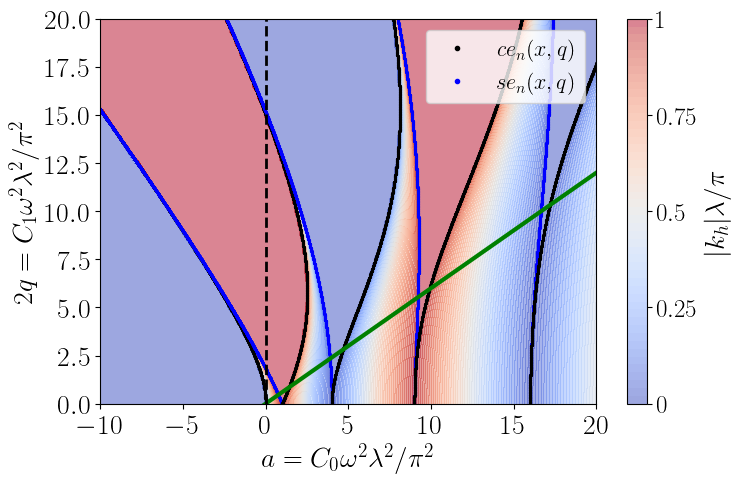

In [39]:
pent = 0.6
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
s0 = eps0*mu0
s1=pent*s0


with open('Map_rho_H12.npy', 'rb') as f:
    aanum = np.load(f)
    qqnum = np.load(f)
    matrho1 = np.load(f)
    matrho2 = np.load(f)
    mats1 = np.load(f)
    mats2 = np.load(f)    

matrho = np.maximum(np.abs(matrho1), np.abs(matrho2))
realsmax = np.maximum(np.real(mats1), np.real(mats2))
#print(realsmax.shape)

mat_row = np.size(aanum)
mat_col = np.size(qqnum)    
    
aanum.shape=(1,mat_row)
qqnum.shape=(1,mat_col)

Mq = np.dot(np.transpose(aanum),np.ones((1,mat_col)))
Mp = np.dot(np.ones((mat_row,1)),qqnum)


imax = 10
listqa = np.ones(imax)
listqb = np.ones(imax)

for ii in range(imax):
    #print(ii)
    [solutiona,solutionb] = solve_mathieu(ii, s0, s1, [2100])
    #[solutiona,solutionb] = solve_mathieu(ii, s0a, s1a, [(s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2])
    solutiona = solutiona[0]
    solutionb = solutionb[0]
    #[solutiona,solutionb] = solve_with_min(ii, s0a, s1a, (ii*10,1000*ii))
    #[solutiona,solutionb] = solve_with_newton(ii, s0a, s1a, (s1a/2)*(2*ii+1)**2*test**2*lamba**2/np.pi**2)
    #solutiona = solutiona[0]
    #solutionb = solutionb[0]    
    #print(solutiona,solutionb)
    listqa[ii] = solutiona
    listqb[ii] = solutionb
    
print(listqa,listqb)

# Define the range of q values
qq = np.linspace(-50, 50, 10000)
aa = np.linspace(-100, 100, 10000)


# Calculate Mathieu function characteristic values
A0e = [mathieu_a(n, qq) for n in range(5)]  # Even modes
A0o = [mathieu_b(n, qq) for n in range(1, 6)]  # Odd modes

# Set font size for plots
fonty = 20
levelou = np.linspace(0.01,(np.amax(np.asarray(realsmax))),100)
leveli = np.linspace(-0.0001,1+0.0001,50)

fig1 = plt.figure(1, figsize=(8, 5))
plt.rc('text', usetex=True)

# Plot characteristic curves with swapped axes
colors = ['k', 'b']
for i, (a, b) in enumerate(zip(A0e, A0o)):
    plt.plot(a, 2*qq, f'{colors[0]}.', markersize=2.5)
    plt.plot(b, 2*qq, f'{colors[1]}.', markersize=2.5)
    
plt.plot(np.NaN, np.NaN, f'{colors[0]}.', markersize=6., label=r'$ce_n(x,q)$')
plt.plot(np.NaN, np.NaN, f'{colors[1]}.', markersize=6., label=r'$se_n(x,q)$')


#sc = plt.scatter(Mq, Mp, c=realsmax, cmap=plt.cm.coolwarm, s=marker_size, alpha=alphadata)
#sc = plt.contourf(Mq,2*Mp,realsmax, cmap=plt.cm.coolwarm,levels=levelou,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,realsmax, 100,cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2))*(Mq+Mp)/2,100, cmap=plt.cm.coolwarm,alpha=0.6)
#sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.6)
sc = plt.contourf(Mq,2*Mp,np.abs(np.imag(mats2)), cmap=plt.cm.coolwarm,levels=leveli,alpha=0.5)


# Colorbar
cbar = plt.colorbar(sc, format='%.1f')

# Set colorbar label and font size
cbar.set_label(r'$|k_h|\lambda/\pi$', fontsize=fonty)  # Adjust font size as needed

# Define the tick locations and corresponding labels
tick_locations = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$', r'$1$']

# Set the ticks and labels
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)

# Set tick parameters for font size
cbar.ax.tick_params(labelsize=fonty-2)  # Adjust font size as needed


# Fill stability regions with swapped axes
#plt.fill_betweenx(2*qq, -100 * np.ones(qq.size), A0e[0], facecolor='b', alpha=0.5)
#for i in range(1, len(A0e)):
#    plt.fill_betweenx(2*qq, A0o[i-1], A0e[i], facecolor='g' if i % 2 else 'b', alpha=0.5)


plt.plot(aa, 2*aa*s1/(2*s0), 'g-',linewidth=3) 
#plt.plot(aa, 2*aa*0.6/2, 'k-',linewidth=2)
plt.plot([0.,0.],[0.,100.], 'k--',linewidth=2) 
#plt.plot([-30.,0.],[30.,0.], 'k--',linewidth=2) 
#plt.plot(aa, -aa*s1/(2*s0), 'k-') 
    
# Customize axes
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlabel(r'$a=C_0\omega^2\lambda^2/\pi^2$', fontsize=fonty)  # x-axis: a
plt.ylabel(r'$2q=C_1\omega^2\lambda^2/\pi^2$', fontsize=fonty)  # y-axis: q
plt.xlim(-10, 20.)
plt.ylim(0.,20.)
#plt.grid()
plt.xscale('linear')
plt.yscale('linear')

# Add legend
plt.legend(fontsize=fonty-4, loc='upper right')

# Show and save the plot
fig1 = plt.gcf()
plt.show()

fig1.savefig('Mathieu_stability_chart_aq_classic.png', format='png', dpi=1000, bbox_inches='tight')

### Floquet eigenvalue computation ($\eta = 0.6$)

Sweeps frequency to compute Floquet multipliers `fexp1`, `fexp2`
for modulation depth $\eta = 0.6$. Used for the dispersion overlay in Fig S1.


In [40]:
# Parameters

TT = np.pi
eps0 = 8.854e-12
mu0 = 1.25663706127e-6
lamb = 1*100e-9
xmax = 10*lamb
s0 = eps0*mu0
#s1 = 0.001*s0
s1=pent*s0

#omega = np.linspace(0.1,10,500)
#aaa = s0*omega**2*lamb**2/np.pi**2
aaa = np.linspace(0.001,25,10000)
qqq = aaa*s1/(2*s0)

fexp1 = np.ones(aaa.size,dtype=complex)
fexp2 = np.ones(aaa.size,dtype=complex)
y_1 = [1., 0.0]
y_2 = [0.0, 1.]
inc = -1
for avis in aaa:
    inc = inc + 1
    # The resolution of the ODE needs to be very accurate DOP853 and Radau seem to do a good job
    #eigenvalues, vecHill = compute_hill_eigenvalues1(avis, qqq[inc], TT)
    eigenvalues = compute_hill_eigenvalues2(avis, qqq[inc], TT)
    fexp1[inc]       = eigenvalues[0]
    fexp2[inc]       = eigenvalues[1]
    #print(fexp1,fexp2)


In [41]:
shift_range = np.arange(-8, 8)

# Extended Brillouin zone: tile by periodicity shifts of 2
eigtot1ext = np.concatenate([np.imag(fexp1) + k*2 for k in shift_range])
eigtot2ext = np.concatenate([np.imag(fexp2) + k*2 for k in shift_range])
aaext = np.tile(aaa, len(shift_range))

# Keep only pass-band points: Re(mu) ~ 0  <=>  |rho| = 1
toto1 = np.where(np.abs(np.real(fexp1)) < 1e-5)
fexp1sort = fexp1[toto1]
aasort1   = aaa[toto1]
toto2 = np.where(np.abs(np.real(fexp2)) < 1e-5)
fexp2sort = fexp2[toto2]
aasort2   = aaa[toto2]

aaextsort1 = np.tile(aasort1, len(shift_range))
aaextsort2 = np.tile(aasort2, len(shift_range))

eigtot1extsort = np.concatenate([np.imag(fexp1sort) + k*2 for k in shift_range])
eigtot2extsort = np.concatenate([np.imag(fexp2sort) + k*2 for k in shift_range])


### → Modulation profile $\varepsilon(x)$ and dispersion — $\eta = 0.6$

Plots $\varepsilon(x)$ over four periods and the Floquet dispersion curve.
Produces `Modulation_positive.png`.


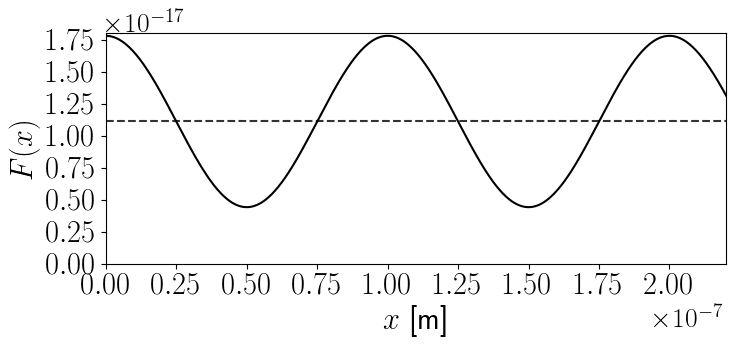

In [42]:
kmax = 1.5e8
vv = 299792458

xplot = np.linspace(0,4*lamb,1000)
yplot = eps0+pent*eps0*np.cos(2*np.pi*xplot/lamb)

fonty = 22
fig1 = plt.figure(1, figsize=(8, 3))
plt.rc('text', usetex=True)

plt.plot(xplot,yplot*mu0,'k-')
#plt.axvline(x=lamb/2+lamb, color='r', linestyle='--', alpha=0.8)
#plt.axvline(x=lamb/2, color='r', linestyle='--', alpha=0.8)
plt.axhline(y=s0, color='k', linestyle='--', alpha=0.8)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$x$ [m]',fontsize=fonty)
plt.ylabel(r'$F(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
plt.xlim(0, 2*lamb+lamb/5)   # set the ylim to ymin, ymax
plt.ylim(0.,1.8e-17)   # set the ylim to ymin, ymax
#plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig1 = plt.gcf()
plt.show()

fig1.savefig('Modulation_positive.png', format='png', dpi=1000, bbox_inches='tight')


### → Figure S2 — Bloch wave profiles at three representative frequencies

Integrates the Floquet ODE at three frequencies and plots $\phi(x)$ and its FFT:
- $\omega_0 = 0.5\times10^{16}$ rad/s — deep **pass band** (propagating Bloch wave)
- $\omega_1 = 1.84\times10^{16}$ rad/s — **Bragg resonance** (stop-band edge)
- $\omega_2 = 3.5\times10^{16}$ rad/s — deep **stop band** (evanescent wave)

Produces `Photonic_omeg0/1/2.png` and `Photonic_omeg0/1/2_FFT.png`.


(-6.323359651256379e-17+0.5355683889329457j) (-6.2405327064266e-17-0.5355683889329457j)
[0.0553497+0.23314926j 0.0553497-0.23314926j]


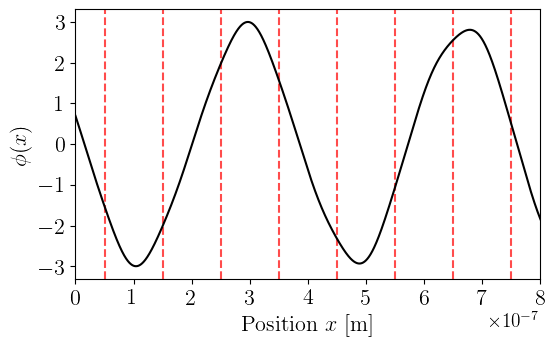

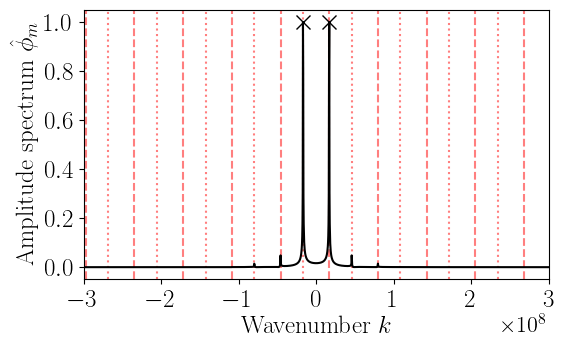

In [43]:
omega0 = 0.5e16
#omega = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega0**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim0, peak_ampadim0 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg0.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim0[int(len(peak_waveadim0)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim0[int(len(peak_waveadim0)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim0, peak_ampadim0,'xk',markersize=10)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg0_FFT.png', format='png', dpi=1000,bbox_inches='tight')



(-1.8012120291421145e-16+0.06414412869658749j) (-1.3922821813778009e-16-0.06414412869658752j)
[-0.10065299-0.4396632j -0.10065299+0.4396632j]


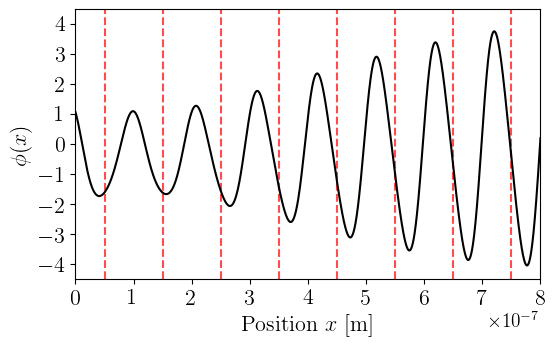

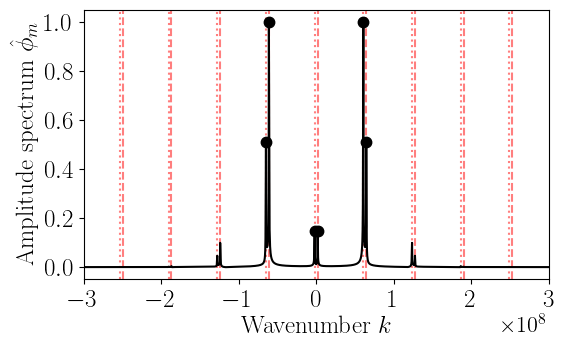

In [44]:
#omega = 1.5e16
omega1 = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega1**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim1, peak_ampadim1 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg1.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim1[int(len(peak_waveadim1)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim1[int(len(peak_waveadim1)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim1, peak_ampadim1,'.k',markersize=15)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg1_FFT.png', format='png', dpi=1000,bbox_inches='tight')


(-3.819960189055278e-16+0.38742490164860716j) (-4.947268429056301e-16-0.38742490164860705j)
[-0.10169812-0.27475606j -0.10169812+0.27475606j]


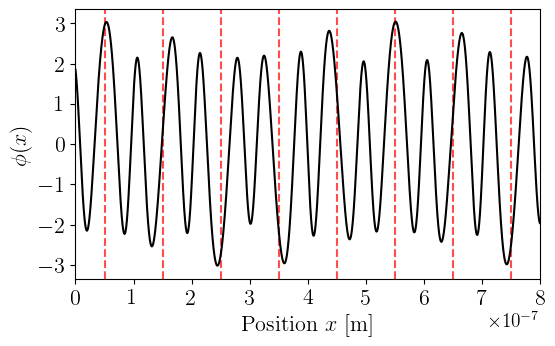

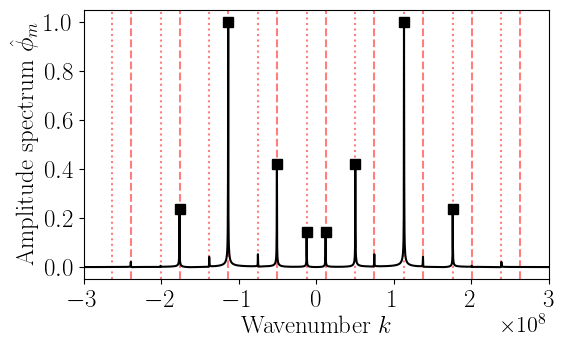

In [45]:
omega2 = 3.5e16
#omega1 = 1.83802e16     #Bragg
nT = int(200)
nTvisu = 8
y0 = np.array([0.1,-0.2])

nprimary = 1000
nFloq = nprimary+1
listcell = np.linspace(0, np.pi, nFloq)
dt = listcell[1]-listcell[0]

listt = np.linspace(0.,np.pi*nT-dt,nT*nprimary)

y_1 = [1.0, 0.0]
y_2 = [0.0, 1.0]

###########################################################################
atest = omega2**2*s0*lamb**2/(np.pi**2)
qtest = atest*s1/(2*s0)


sol1 = solve_ivp(equation_lin, [0, np.pi], y_1, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
sol2 = solve_ivp(equation_lin, [0, np.pi], y_2, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=None,args=(atest, qtest))
# Assembly of the monodromy matrix Phi
mat_phi = np.array([ [ sol1.y[0,-1], sol2.y[0,-1]  ] , [ sol1.y[1,-1], sol2.y[1,-1] ] ],dtype=complex)
eigenValues, eigenVectors = scipy.linalg.eig(mat_phi)
rho1 = eigenValues[0]
rho2 = eigenValues[1]
eigVector1 = eigenVectors[:,0]
eigVector2 = eigenVectors[:,1]
ff1         = cm.log(rho1)/np.pi
ff2         = cm.log(rho2)/np.pi

print(ff1,ff2)    

#The Floquet form computation
mode_floquet1 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector1, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff1)) 
mode_floquet2 = solve_ivp(sol_comp_mode_floquet, [0, np.pi], eigVector2, method='RK45',rtol=1e-14,atol=1e-18,
                t_eval=listcell,args=(atest, qtest, ff2))


# Reconstruction of a response with Floquet forms superposition
cci = np.dot(np.linalg.inv(eigenVectors),y0)
print(cci)

MAtFloq = np.zeros((nT,nprimary),dtype=complex)
MAtFloqp = np.zeros((nT,nprimary),dtype=complex)

for ii in range(nT):
    MAtFloq[ii,:] = cci[0]*mode_floquet1.y[0,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[0,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))
    MAtFloqp[ii,:] = cci[0]*mode_floquet1.y[1,0:-1:1]*np.exp(ff1*(listcell[0:-1:1]+ii*2*np.pi))+\
    cci[1]*mode_floquet2.y[1,0:-1:1]*np.exp(ff2*(listcell[0:-1:1]+ii*np.pi))

qlist0 = MAtFloq.reshape((int(nT*nprimary),))
qplist0 = MAtFloqp.reshape((int(nT*nprimary),))


solist = solve_ivp(equation_lin, [0, np.pi*nT-dt], y0, method='DOP853',rtol=1e-14,atol=1e-18,
                t_eval=listt,args=(atest, qtest))
q0 = solist.y[0,:]
qp0 = solist.y[1,:]


# Compute the FFT
L = np.max(listt*lamb/np.pi)
wave = np.real(q0)
# Length of the wave
N_wave = len(wave)
# Choose FFT length (must match the length of the wave for FFT)
N = N_wave  # Use the actual wave length for FFT
fft_wave = np.fft.fft(wave)
fft_wave = fft_wave / N  # Normalize the amplitude
# Compute the wavenumbers
k = 2 * np.pi * np.fft.fftfreq(N, d=L / N)  # Wavenumbers
k = np.fft.fftshift(k)                      # Shift wavenumbers
# Shift the FFT for symmetry
fft_wave_shifted = np.fft.fftshift(fft_wave)

# Find peaks
peak_wavenumbers, peak_amplitudes = find_fft_peaks(fft_wave_shifted, k, height=0.001, distance=10)
fftadim =  np.abs(fft_wave_shifted)/np.max(peak_amplitudes)
q0adim = np.real(q0)/np.max(peak_amplitudes)
peak_waveadim2, peak_ampadim2 = find_fft_peaks(fftadim, k, height=0.1, distance=1)

indou = np.argmax(peak_amplitudes)
kfund = peak_wavenumbers[indou]

fonty = 16
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(0, nTvisu):
    x_pos = i * lamb + 0.5*lamb
    plt.axvline(x=x_pos, color='r', linestyle='--', alpha=0.7)

#plt.plot(listt,np.real(qlist0),'g-',linewidth=1.5)
#plt.plot(listt*lamb/np.pi,np.real(q0),'k-',linewidth=1.5)
plt.plot(listt*lamb/np.pi,q0adim,'k-',linewidth=1.5)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlim(0, nTvisu*lamb)   # set the ylim to ymin, ymax
plt.xlabel(r'$\mathrm{Position}$ $x$ $\mathrm{[m]}$',fontsize=fonty)
plt.ylabel(r'$\phi(x)$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg2.png', format='png', dpi=1000,bbox_inches='tight')



fonty = 18
fig5 = plt.figure(5, figsize=(6, 3.5))
plt.rc('text', usetex=True)

# Add vertical dashed lines
for i in range(-5,5):
    x_pos1 = peak_waveadim2[int(len(peak_waveadim2)/2)] + i * (2*np.pi / lamb)
    x_pos2 = peak_waveadim2[int(len(peak_waveadim2)/2-1)] + i * (2*np.pi / lamb)
    plt.axvline(x=x_pos1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=x_pos2, color='r', linestyle=':', alpha=0.5)

#plt.plot(listt,np.real(qplist0),'g-',linewidth=1.5)
#plt.axvline(x=np.abs(kfund), color='b', linestyle='--', alpha=0.7)
#plt.axvline(x=-np.abs(kfund), color='b', linestyle='--', alpha=0.7)
plt.plot(k, fftadim,'k')
plt.plot(peak_waveadim2, peak_ampadim2,'sk',markersize=7)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-2)
#ax.yaxis.get_offset_text().set_fontsize(fonty-2)

plt.xlabel(r'$\mathrm{Wavenumber}$ $k$',fontsize=fonty)
#plt.ylabel(r'Amplitude spectrum $\hat{\phi}_m = \sum_{n=0}^{N-1} \phi_n e^{-i \frac{2\pi}{N} m n}$',fontsize=fonty)
plt.ylabel(r'$\mathrm{Amplitude}$ $\mathrm{spectrum}$ $\hat{\phi}_m$',fontsize=fonty)
plt.xlim(-2*kmax, 2*kmax)   # set the ylim to ymin, ymax
plt.xticks(size=fonty)
plt.yticks(size=fonty)
#legend = plt.legend(fontsize=fonty,loc='best')
fig5 = plt.gcf()
plt.show()

fig5.savefig('Photonic_omeg2_FFT.png', format='png', dpi=1000,bbox_inches='tight')


### → Dispersion relation — extended and fundamental Brillouin zones

Assembles the Floquet dispersion $\omega(k)$ in both the extended zone
(all bands) and the reduced first Brillouin zone.
Produces `Dispersion_relation_extended.png` and `Dispersion_relation_fundamental.png`.


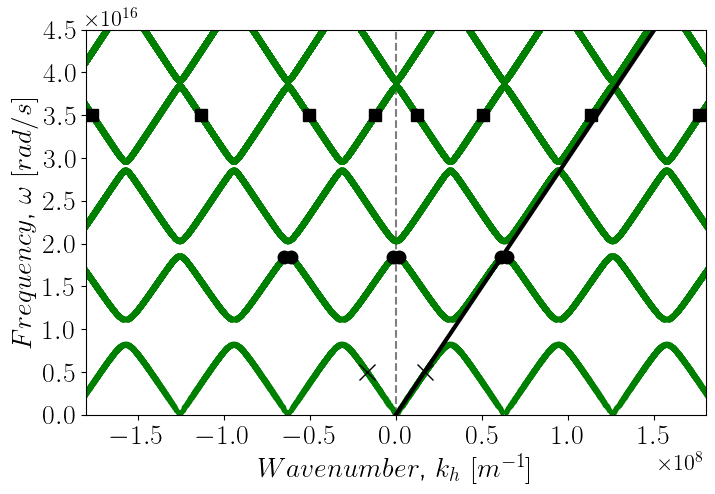

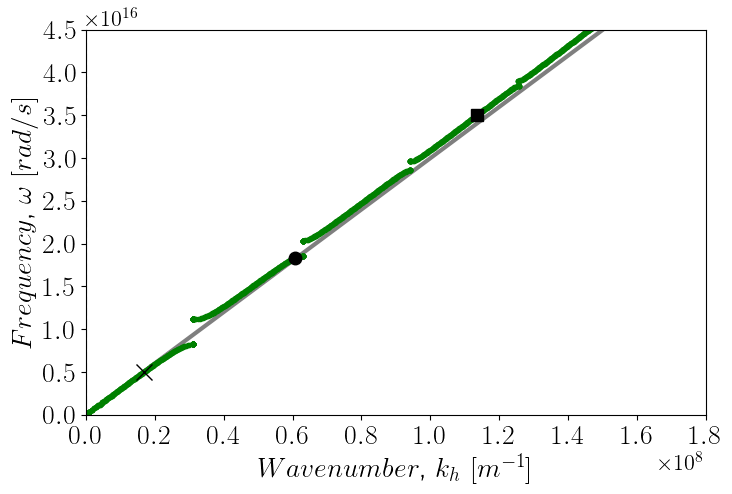

In [46]:
kmax = 1.5e8
ymax = 4.5e16
num_lines = 5
fonty = 20


# Example noisy data
X_noisy = np.concatenate([np.pi*eigtot1extsort/lamb,np.pi*eigtot2extsort/lamb])  # X values
Y_noisy = np.concatenate([np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb,np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb])

# Known line parameters (e.g., Y = mX + c)
m_known = vv*1.02  # Slope of the known line

# Step 1: Define your new set of X values (independently)
X_new = np.linspace(0, kmax, 1000)  # For example, create 100 new X values between 0 and 10

# Step 2: Compute the corresponding Y values for these new X values using the known line
Y_new = m_known * X_new  # Equation of the known line

# Step 3: For each (X_new, Y_new), find the closest point in the noisy data
X_closest = np.zeros(len(X_new))
Y_closest = np.zeros(len(X_new))

for i, (x_new, y_new) in enumerate(zip(X_new, Y_new)):
    # Calculate the distance from (X_new, Y_new) to all points in (X_noisy, Y_noisy)
    distances = np.sqrt((X_noisy - x_new)**2 + (Y_noisy - y_new)**2)
    
    # Find the index of the closest point in the noisy data
    closest_idx = np.argmin(distances)
    
    # Store the closest X and Y values
    X_closest[i] = X_noisy[closest_idx]
    Y_closest[i] = Y_noisy[closest_idx]

distance0 = (Y_closest - omega0)**2
# Find the index of the closest point in the noisy data
closest_idx0 = np.argmin(distance0)
X_closest0 = X_closest[closest_idx0]
Y_closest0 = Y_closest[closest_idx0]

distance1 = (Y_closest - omega1)**2
# Find the index of the closest point in the noisy data
closest_idx1 = np.argmin(distance1)
X_closest1 = X_closest[closest_idx1]
Y_closest1 = Y_closest[closest_idx1]

distance2 = (Y_closest - omega2)**2
# Find the index of the closest point in the noisy data
closest_idx2 = np.argmin(distance2)
X_closest2 = X_closest[closest_idx2]
Y_closest2 = Y_closest[closest_idx2]


fig3 = plt.figure(3, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=1)
plt.plot(peak_waveadim2, omega2*np.ones(peak_waveadim2.size),'sk',markersize=8)
plt.plot(peak_waveadim1, omega1*np.ones(peak_waveadim1.size),'.k',markersize=18)
plt.plot(peak_waveadim0, omega0*np.ones(peak_waveadim0.size),'xk',markersize=12)
#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(-1.2*kmax, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig3 = plt.gcf()
plt.show()

fig3.savefig('Dispersion_relation_extended.png', format='png', dpi=1000, bbox_inches='tight')



fig4 = plt.figure(4, figsize=(8, 5))
plt.rc('text', usetex=True)

plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
# Add vertical dashed lines
for i in range(1, num_lines + 1):
    x_pos = i * np.pi / lamb
    #plt.axvline(x=x_pos, color='g', linestyle='--', alpha=0.7)

#plt.plot(np.pi*eigtot1extsort/lamb, np.pi*np.sqrt(aaextsort1)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
#plt.plot(np.pi*eigtot2extsort/lamb, np.pi*np.sqrt(aaextsort2)/np.sqrt(np.abs(s0))/lamb, 'g.',linewidth=1.)
plt.plot([0,kmax], [0,vv*kmax], 'k-',linewidth=3.,alpha=0.5)
plt.plot(X_closest, Y_closest, 'g.',linewidth=1.)
plt.plot(X_closest2, Y_closest2,'sk',markersize=8)
plt.plot(X_closest1, Y_closest1,'.k',markersize=18)
plt.plot(X_closest0, Y_closest0,'xk',markersize=12)

#legend = plt.legend(fontsize=fonty,loc='right')
plt.xlabel(r'$Wavenumber$, $k_h$ $[m^{-1}]$',fontsize=fonty)
plt.ylabel(r'$Frequency$, $\omega$ $[rad/s]$',fontsize=fonty)
plt.xticks(size=fonty)
plt.yticks(size=fonty)

# Set font size for the offset text
ax = plt.gca()
ax.xaxis.get_offset_text().set_fontsize(fonty-4)
ax.yaxis.get_offset_text().set_fontsize(fonty-4)

plt.xlim(0, 1.2*kmax)   # set the ylim to ymin, ymax
#plt.xlim(0.,40)   # set the ylim to ymin, ymax
plt.ylim(0., ymax)   # set the ylim to ymin, ymax
#plt.grid()
plt.yscale('linear')
fig4 = plt.gcf()
plt.show()

fig4.savefig('Dispersion_relation_fundamental.png', format='png', dpi=1000, bbox_inches='tight')







## By Arnaud Lazarus - 06/13/2026